In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv('train.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_index(inplace=True)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
df2 = pd.read_csv('stores.csv')
df2.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [4]:

df = df.merge(df2, how='left', on='Store')
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df.set_index('Date', inplace=True)
df = df.groupby([df.index, df['Type']]).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df = df.reset_index(level='Type')
df = df.reset_index(level='Date')
df1 = df[df['Type'] == 'A']
df2 = df[df['Type'] == 'B']
df3 = df[df['Type'] == 'C']

In [5]:
test_df = pd.read_csv('test.csv')
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df.sort_index(inplace=True)
test_df.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [6]:
df = pd.concat([df1, test_df], axis=0)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df = df.groupby(df.index).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df.sort_index(inplace=True)
df.head()

,Weekly_Sales,IsHoliday
Date,,
2010-02-05,32144126.25,False
2010-02-12,30982570.79,True
2010-02-19,31000072.76,False
2010-02-26,28008995.99,False
2010-03-05,30020543.60,False


In [7]:
df['lag1'] = df['Weekly_Sales'].shift(1)

df['lag2'] = df['Weekly_Sales'].shift(2)

df['lag3'] = df['Weekly_Sales'].shift(3)

df['lag4'] = df['Weekly_Sales'].shift(4)

df['lag5'] = df['Weekly_Sales'].shift(5)

df['lag6'] = df['Weekly_Sales'].shift(6)

df['lag7'] = df['Weekly_Sales'].shift(7)

df['month'] = df.index.month

df['week'] = (df.index.day - 1) // 7 + 1

df['scales_change'] = df['Weekly_Sales'].pct_change().shift(1) # velocity in Sales growth

df['Pre_Holiday_Week'] =  df['IsHoliday'].shift(-1).astype(bool)

df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()

df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()

df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()

df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()

df['moving_min'] = df['Weekly_Sales'].shift(1).rolling(window=4).mean()

df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()


df.head()

,Weekly_Sales,IsHoliday,lag1,lag2,lag3,lag4,lag5,lag6,lag7,month,week,scales_change,Pre_Holiday_Week,moving_avg,moving_median,moving_std,moving_max,moving_min,moving_sum
Date,,,,,,,,,,,,,,,,,,,
2010-02-05,32144126.25,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-12,30982570.79,True,32144126.25,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-19,31000072.76,False,30982570.79,32144126.25,NaN,NaN,NaN,NaN,NaN,2,3,-0.036136,False,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-26,28008995.99,False,31000072.76,30982570.79,32144126.25,NaN,NaN,NaN,NaN,2,4,0.000565,False,3.053394e+07,3.099132e+07,1.768859e+06,32144126.25,NaN,1.221358e+08
2010-03-05,30020543.60,False,28008995.99,31000072.76,30982570.79,32144126.25,NaN,NaN,NaN,3,1,-0.096486,False,3.000305e+07,3.050156e+07,1.405948e+06,31000072.76,3.053394e+07,1.200122e+08


In [8]:
df.columns.nunique()

19

In [9]:
xgb_A = joblib.load('grid_xgb_A.pkl')
xgb_B = joblib.load('xgb_B.pkl')
xgb_C = joblib.load('grid_xgb_c.pkl')

In [10]:
forecast_dates = df.index[df.index >= '2012-11-02']

features = [
    'IsHoliday', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 
    'month', 'week', 'scales_change', 'Pre_Holiday_Week', 
    'moving_avg', 'moving_median', 'moving_std', 'moving_max', 'moving_min', 'moving_sum'
]


for date in forecast_dates:
    X_current = df.loc[[date], features]

    df.loc[date, 'Weekly_Sales'] = xgb_A.predict(X_current)[0]
    # Recalculate rolling features based on the new prediction # month and week are already calculated
    df['lag1'] = df['Weekly_Sales'].shift(1)
    df['lag2'] = df['Weekly_Sales'].shift(2)
    df['lag3'] = df['Weekly_Sales'].shift(3)
    df['lag4'] = df['Weekly_Sales'].shift(4)
    df['lag5'] = df['Weekly_Sales'].shift(5)
    df['lag6'] = df['Weekly_Sales'].shift(6)
    df['lag7'] = df['Weekly_Sales'].shift(7)
    df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()
    df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()
    df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()
    df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()
    df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()

In [11]:
predicted_sales_of_A_on_unseen_data = df['2012-11-02':]['Weekly_Sales']

In [12]:
df = pd.DataFrame(predicted_sales_of_A_on_unseen_data)
df.head()

,Weekly_Sales
Date,
2012-11-02,32085602.0
2012-11-09,30730864.0
2012-11-16,29167494.0
2012-11-23,29019954.0
2012-11-30,29723944.0


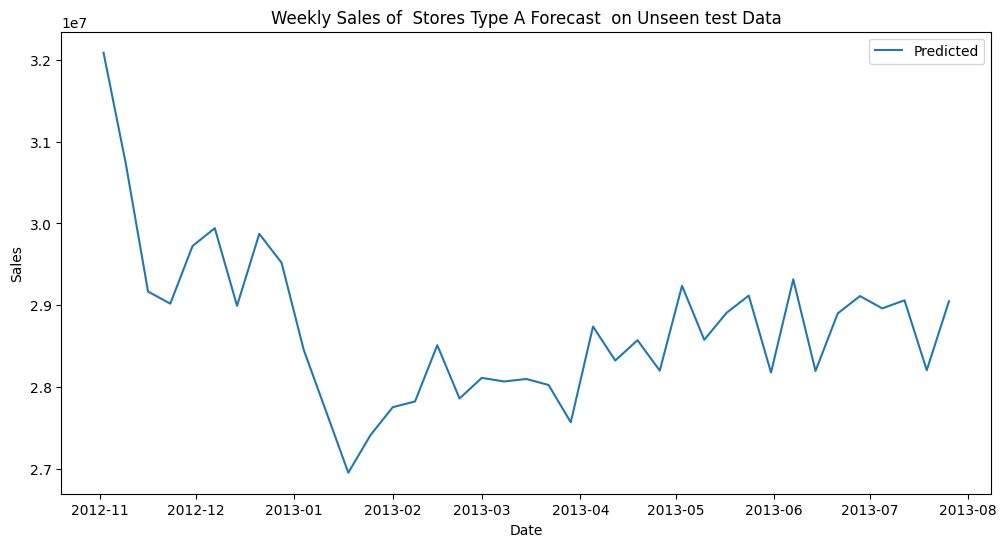

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Weekly_Sales'], label='Predicted')
plt.title('Weekly Sales of  Stores Type A Forecast  on Unseen test Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [14]:
df.to_csv('forecasted_sales_of_A.csv', index=True)

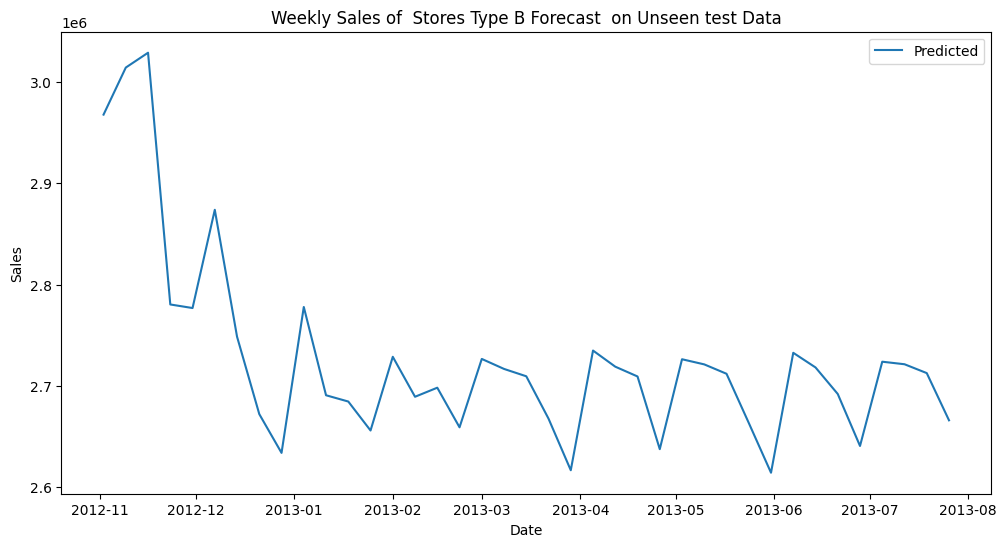

In [15]:
df = pd.concat([df2, test_df], axis=0)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df = df.groupby(df.index).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df.sort_index(inplace=True)
df.head()
df['lag1'] = df['Weekly_Sales'].shift(1)

df['lag2'] = df['Weekly_Sales'].shift(2)

df['lag3'] = df['Weekly_Sales'].shift(3)

df['lag4'] = df['Weekly_Sales'].shift(4)

df['lag5'] = df['Weekly_Sales'].shift(5)

df['lag6'] = df['Weekly_Sales'].shift(6)

df['lag7'] = df['Weekly_Sales'].shift(7)

df['month'] = df.index.month

df['week'] = (df.index.day - 1) // 7 + 1

df['scales_change'] = df['Weekly_Sales'].pct_change().shift(1) # velocity in Sales growth

df['Pre_Holiday_Week'] =  df['IsHoliday'].shift(-1).astype(bool)

df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()

df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()

df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()

df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()

df['moving_min'] = df['Weekly_Sales'].shift(1).rolling(window=4).mean()

df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()


df.head()

forecast_dates = df.index[df.index >= '2012-11-02']

features = [
    'IsHoliday', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 
    'month', 'week', 'scales_change', 'Pre_Holiday_Week', 
    'moving_avg', 'moving_median', 'moving_std', 'moving_max', 'moving_min', 'moving_sum'
]


for date in forecast_dates:
    X_current = df.loc[[date], features]

    df.loc[date, 'Weekly_Sales'] = xgb_B.predict(X_current)[0]
    # Recalculate rolling features based on the new prediction # month and week are already calculated
    df['lag1'] = df['Weekly_Sales'].shift(1)
    df['lag2'] = df['Weekly_Sales'].shift(2)
    df['lag3'] = df['Weekly_Sales'].shift(3)
    df['lag4'] = df['Weekly_Sales'].shift(4)
    df['lag5'] = df['Weekly_Sales'].shift(5)
    df['lag6'] = df['Weekly_Sales'].shift(6)
    df['lag7'] = df['Weekly_Sales'].shift(7)
    df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()
    df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()
    df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()
    df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()
    df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()

predicted_sales_of_B_on_unseen_data = df['2012-11-02':]['Weekly_Sales']
df = pd.DataFrame(predicted_sales_of_B_on_unseen_data)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Weekly_Sales'], label='Predicted')
plt.title('Weekly Sales of  Stores Type B Forecast  on Unseen test Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

df.to_csv('forecasted_sales_of_B.csv', index=True)

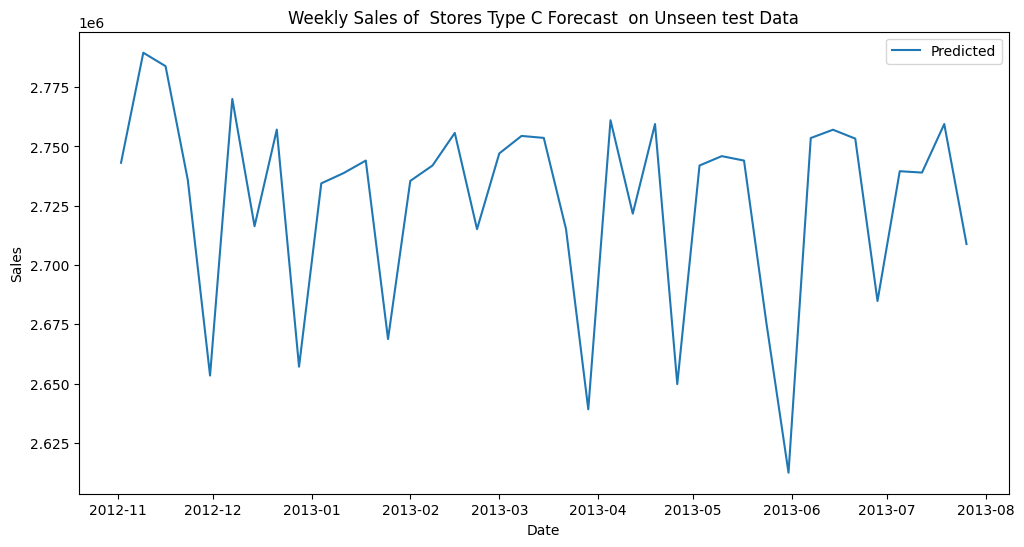

In [16]:
df = pd.concat([df3, test_df], axis=0)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df = df.groupby(df.index).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df.sort_index(inplace=True)
df.head()
df['lag1'] = df['Weekly_Sales'].shift(1)

df['lag2'] = df['Weekly_Sales'].shift(2)

df['lag3'] = df['Weekly_Sales'].shift(3)

df['lag4'] = df['Weekly_Sales'].shift(4)

df['lag5'] = df['Weekly_Sales'].shift(5)

df['lag6'] = df['Weekly_Sales'].shift(6)

df['lag7'] = df['Weekly_Sales'].shift(7)

df['month'] = df.index.month

df['week'] = (df.index.day - 1) // 7 + 1

df['scales_change'] = df['Weekly_Sales'].pct_change().shift(1) # velocity in Sales growth

df['Pre_Holiday_Week'] =  df['IsHoliday'].shift(-1).astype(bool)

df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()

df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()

df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()

df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()

df['moving_min'] = df['Weekly_Sales'].shift(1).rolling(window=4).mean()

df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()


df.head()

forecast_dates = df.index[df.index >= '2012-11-02']

features = [
    'IsHoliday', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 
    'month', 'week', 'scales_change', 'Pre_Holiday_Week', 
    'moving_avg', 'moving_median', 'moving_std', 'moving_max', 'moving_min', 'moving_sum'
]


for date in forecast_dates:
    X_current = df.loc[[date], features]

    df.loc[date, 'Weekly_Sales'] = xgb_C.predict(X_current)[0]
    # Recalculate rolling features based on the new prediction # month and week are already calculated
    df['lag1'] = df['Weekly_Sales'].shift(1)
    df['lag2'] = df['Weekly_Sales'].shift(2)
    df['lag3'] = df['Weekly_Sales'].shift(3)
    df['lag4'] = df['Weekly_Sales'].shift(4)
    df['lag5'] = df['Weekly_Sales'].shift(5)
    df['lag6'] = df['Weekly_Sales'].shift(6)
    df['lag7'] = df['Weekly_Sales'].shift(7)
    df['moving_avg'] = df['Weekly_Sales'].rolling(window=4).mean()
    df['moving_median'] = df['Weekly_Sales'].rolling(window=4).median()
    df['moving_std'] = df['Weekly_Sales'].rolling(window=4).std()
    df['moving_max'] = df['Weekly_Sales'].rolling(window=4).max()
    df['moving_sum'] = df['Weekly_Sales'].rolling(window=4).sum()

predicted_sales_of_C_on_unseen_data = df['2012-11-02':]['Weekly_Sales']
df = pd.DataFrame(predicted_sales_of_C_on_unseen_data)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Weekly_Sales'], label='Predicted')
plt.title('Weekly Sales of  Stores Type C Forecast  on Unseen test Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

df.to_csv('forecasted_sales_of_C.csv', index=True)